In [3]:
import pandas as pd

df = pd.read_excel('/content/merged_output(1).xlsx')
print("DataFrame loaded successfully. Displaying the first 5 rows:")
df.head()

DataFrame loaded successfully. Displaying the first 5 rows:


,Publication Type,Authors,Book Authors,Book Editors,Book Group Authors,Author Full Names,Book Author Full Names,Group Authors,Article Title,Source Title,...,Web of Science Index,Research Areas,IDS Number,Pubmed Id,Open Access Designations,Highly Cited Status,Hot Paper Status,Date of Export,UT (Unique WOS ID),Web of Science Record
0,C,"Ren, XB; Xia, LH; Yang, YH; Wei, W; Wang, TL; ...",NaN,NaN,Assoc computing machinery,"Ren, Xubin; Xia, Lianghao; Yang, Yuhao; Wei, W...",NaN,NaN,SSLRec: A Self-Supervised Learning Framework f...,PROCEEDINGS OF THE 17TH ACM INTERNATIONAL CONF...,...,Conference Proceedings Citation Index - Scienc...,Computer Science,BW6TN,NaN,NaN,NaN,NaN,2025-08-30,WOS:001182230100065,0
1,J,"Abolghasemi, R; Viedma, EH; Engelstad, P; Djen...",NaN,NaN,NaN,"Abolghasemi, Roza; Viedma, Enrique Herrera; En...",NaN,NaN,A graph neural approach for group recommendati...,INFORMATION FUSION,...,Science Citation Index Expanded (SCI-EXPANDED),Computer Science,QK1U9,NaN,"Green Submitted, hybrid",NaN,NaN,2025-08-30,WOS:001220685000001,0
2,J,"Bhatia, V",NaN,NaN,NaN,"Bhatia, Vandana",NaN,NaN,DLSF: Deep learning and semantic fusion based ...,EXPERT SYSTEMS WITH APPLICATIONS,...,Science Citation Index Expanded (SCI-EXPANDED),Computer Science; Engineering; Operations Rese...,QX9S9,NaN,NaN,NaN,NaN,2025-08-30,WOS:001224291200001,0
3,J,"Wang, XF; Zhang, ZJ; Shen, GD; Lai, SM; Chen, ...",NaN,NaN,NaN,"Wang, Xiaofeng; Zhang, Zengjie; Shen, Guodong;...",NaN,NaN,Multi-view knowledge graph convolutional netwo...,APPLIED SOFT COMPUTING,...,Science Citation Index Expanded (SCI-EXPANDED),Computer Science,R9M0R,NaN,NaN,NaN,NaN,2025-08-30,WOS:001394585300001,0
4,J,"Yang, F; Peng, DL; Zhang, S",NaN,NaN,NaN,"Yang, Fan; Peng, Dunlu; Zhang, Shuo",NaN,NaN,Self-supervised hypergraph neural network for ...,APPLIED SOFT COMPUTING,...,Science Citation Index Expanded (SCI-EXPANDED),Computer Science,MZ5A4,NaN,NaN,NaN,NaN,2025-08-30,WOS:001197458100001,0


In [4]:
!pip install transformers

In [5]:
!pip install torch

In [6]:
from transformers import pipeline
sentiment_pipeline = pipeline('sentiment-analysis')
print("Sentiment analysis pipeline loaded successfully.")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Sentiment analysis pipeline loaded successfully.


In [7]:
df['Abstract'] = df['Abstract'].fillna('').apply(lambda x: x[:512])
sentiment_results = sentiment_pipeline(df['Abstract'].tolist())
df['sentiment'] = [result['label'] for result in sentiment_results]
df['sentiment_score'] = [result['score'] for result in sentiment_results]
print("Sentiment analysis completed for the 'Abstract' column.")
print(df[['Abstract', 'sentiment', 'sentiment_score']].head())

Sentiment analysis completed for the 'Abstract' column.
                                            Abstract sentiment  \
0  Self-supervised learning (SSL) has gained sign...  NEGATIVE   
1  Pairwise preference information, which involve...  POSITIVE   
2  An intelligent recommendation system facilitat...  NEGATIVE   
3  Recommender systems based on knowledge graphs ...  NEGATIVE   
4  Session -based recommendation aims to predict ...  NEGATIVE   

   sentiment_score  
0         0.998467  
1         0.897573  
2         0.863543  
3         0.995380  
4         0.985491  


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries for visualization imported successfully.")

Libraries for visualization imported successfully.


/tmp/ipython-input-974502643.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


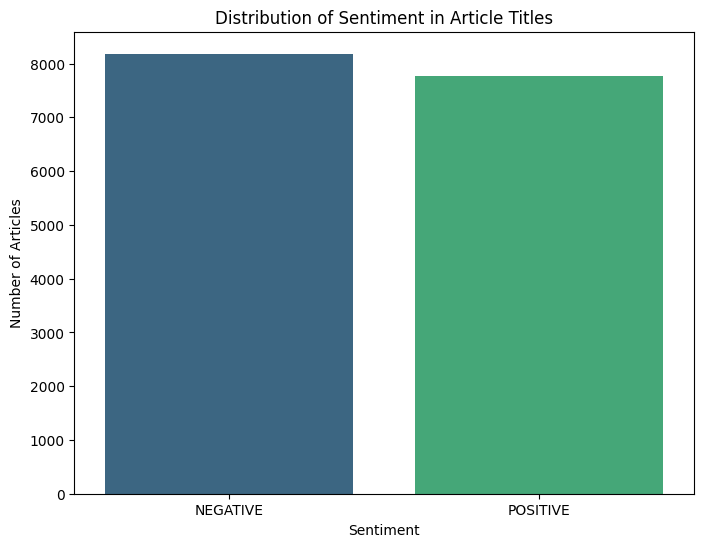

Sentiment distribution visualization completed.


In [9]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiment in Article Titles')
plt.xlabel('Sentiment')
plt.ylabel('Number of Articles')
plt.show()
print("Sentiment distribution visualization completed.")

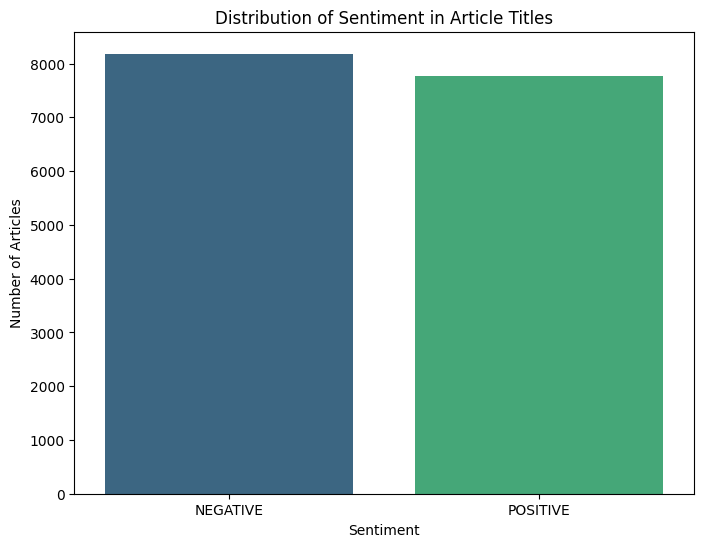

Sentiment distribution visualization completed.

Sentiment Distribution:
sentiment
NEGATIVE    8183
POSITIVE    7761
Name: count, dtype: int64

Summary of Sentiment Analysis:
The majority of article titles (51.32%) were classified as 'NEGATIVE'. The remaining 48.68% were classified as 'POSITIVE'.


In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis', hue='sentiment', legend=False)
plt.title('Distribution of Sentiment in Article Titles')
plt.xlabel('Sentiment')
plt.ylabel('Number of Articles')
plt.show()
print("Sentiment distribution visualization completed.")

sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:")
print(sentiment_counts)

most_common_sentiment = sentiment_counts.idxmax()
percentage_most_common = (sentiment_counts.max() / sentiment_counts.sum()) * 100

summary = f"\nSummary of Sentiment Analysis:\n"
summary += f"The majority of article titles ({percentage_most_common:.2f}%) were classified as '{most_common_sentiment}'."
if len(sentiment_counts) > 1:
    least_common_sentiment = sentiment_counts.idxmin()
    percentage_least_common = (sentiment_counts.min() / sentiment_counts.sum()) * 100
    summary += f" The remaining {percentage_least_common:.2f}% were classified as '{least_common_sentiment}'."
else:
    summary += f" All article titles were classified as '{most_common_sentiment}'."

print(summary)

In [11]:
from transformers import pipeline

sentiment_pipeline_model2 = pipeline('sentiment-analysis', model='cardiffnlp/twitter-roberta-base-sentiment-latest')
print("Second sentiment analysis pipeline loaded successfully with 'cardiffnlp/twitter-roberta-base-sentiment-latest'.")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Second sentiment analysis pipeline loaded successfully with 'cardiffnlp/twitter-roberta-base-sentiment-latest'.


In [12]:
import pandas as pd

df = pd.read_excel('/content/merged_output(1).xlsx')

df['Abstract'] = df['Abstract'].fillna('').apply(lambda x: x[:512])
sentiment_results_model2 = sentiment_pipeline_model2(df['Abstract'].tolist())
df['sentiment_model2'] = [result['label'] for result in sentiment_results_model2]
df['sentiment_score_model2'] = [result['score'] for result in sentiment_results_model2]
print("Sentiment analysis completed for the 'Abstract' column using the second model.")
print(df[['Abstract', 'sentiment_model2', 'sentiment_score_model2']].head())

Sentiment analysis completed for the 'Abstract' column using the second model.
                                            Abstract sentiment_model2  \
0  Self-supervised learning (SSL) has gained sign...          neutral   
1  Pairwise preference information, which involve...          neutral   
2  An intelligent recommendation system facilitat...          neutral   
3  Recommender systems based on knowledge graphs ...          neutral   
4  Session -based recommendation aims to predict ...          neutral   

   sentiment_score_model2  
0                0.665479  
1                0.668253  
2                0.821472  
3                0.755061  
4                0.774992  


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


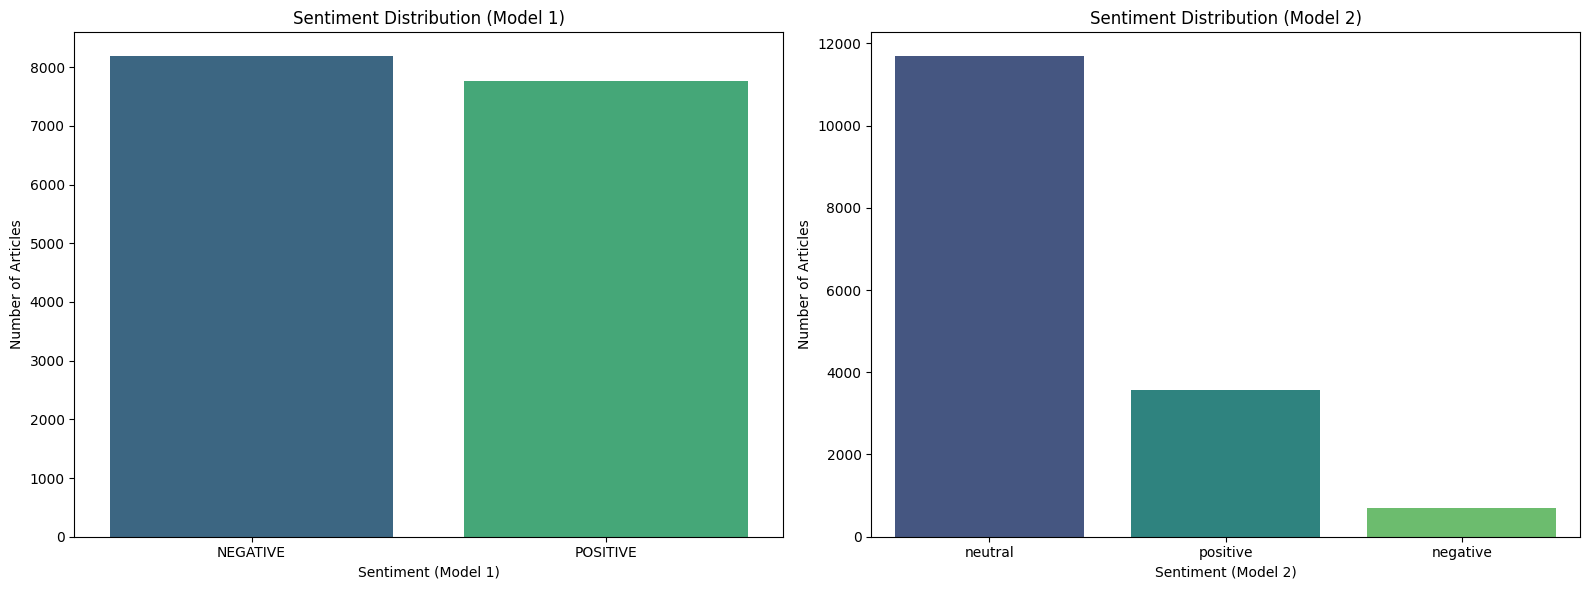

Sentiment distributions from both models visualized successfully.


In [13]:
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sentiment_pipeline = pipeline('sentiment-analysis')

df = pd.read_excel('/content/merged_output(1).xlsx')

df['Abstract'] = df['Abstract'].fillna('').apply(lambda x: x[:512])

sentiment_results = sentiment_pipeline(df['Abstract'].tolist())
df['sentiment'] = [result['label'] for result in sentiment_results]
df['sentiment_score'] = [result['score'] for result in sentiment_results]

sentiment_pipeline_model2 = pipeline('sentiment-analysis', model='cardiffnlp/twitter-roberta-base-sentiment-latest')

sentiment_results_model2 = sentiment_pipeline_model2(df['Abstract'].tolist())
df['sentiment_model2'] = [result['label'] for result in sentiment_results_model2]
df['sentiment_score_model2'] = [result['score'] for result in sentiment_results_model2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='sentiment', data=df, palette='viridis', ax=ax1, hue='sentiment', legend=False)
ax1.set_title('Sentiment Distribution (Model 1)')
ax1.set_xlabel('Sentiment (Model 1)')
ax1.set_ylabel('Number of Articles')

sns.countplot(x='sentiment_model2', data=df, palette='viridis', ax=ax2, hue='sentiment_model2', legend=False)
ax2.set_title('Sentiment Distribution (Model 2)')
ax2.set_xlabel('Sentiment (Model 2)')
ax2.set_ylabel('Number of Articles')

plt.tight_layout()
plt.show()
print("Sentiment distributions from both models visualized successfully.")

In [21]:
from transformers import pipeline

sentiment_pipeline_alt = pipeline('sentiment-analysis', model='finiteautomata/bertweet-base-sentiment-analysis', device=-1) # Force CPU usage
print("Alternative sentiment analysis pipeline (bertweet-base) loaded successfully and set to use CPU.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Alternative sentiment analysis pipeline (bertweet-base) loaded successfully and set to use CPU.


In [22]:
sentiment_pipeline_bert_sst2 = pipeline('sentiment-analysis', model='textattack/bert-base-uncased-SST-2', device=-1)
print("bert-base-uncased-finetuned-sst2 sentiment analysis pipeline loaded successfully and set to use CPU.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

bert-base-uncased-finetuned-sst2 sentiment analysis pipeline loaded successfully and set to use CPU.


In [23]:
alt_results = sentiment_pipeline_alt(df['Abstract'].tolist(), truncation=True)
df['sentiment_alt'] = [result['label'] for result in alt_results]
df['sentiment_score_alt'] = [result['score'] for result in alt_results]

bert_sst2_results = sentiment_pipeline_bert_sst2(df['Abstract'].tolist(), truncation=True)
df['sentiment_bert_sst2'] = [result['label'] for result in bert_sst2_results]
df['sentiment_score_bert_sst2'] = [result['score'] for result in bert_sst2_results]

print("Sentiment analysis completed for the 'Abstract' column using the alternative model and bert-base-uncased-finetuned-sst2.")
print(df[['Abstract', 'sentiment_alt', 'sentiment_score_alt', 'sentiment_bert_sst2', 'sentiment_score_bert_sst2']].head())

Sentiment analysis completed for the 'Abstract' column using the alternative model and bert-base-uncased-finetuned-sst2.
                                            Abstract sentiment_alt  \
0  Self-supervised learning (SSL) has gained sign...           NEU   
1  Pairwise preference information, which involve...           NEU   
2  An intelligent recommendation system facilitat...           POS   
3  Recommender systems based on knowledge graphs ...           NEU   
4  Session -based recommendation aims to predict ...           NEU   

   sentiment_score_alt sentiment_bert_sst2  sentiment_score_bert_sst2  
0             0.665929             LABEL_0                   0.942498  
1             0.648851             LABEL_1                   0.930586  
2             0.641918             LABEL_0                   0.837328  
3             0.552138             LABEL_0                   0.924440  
4             0.701571             LABEL_0                   0.963122  


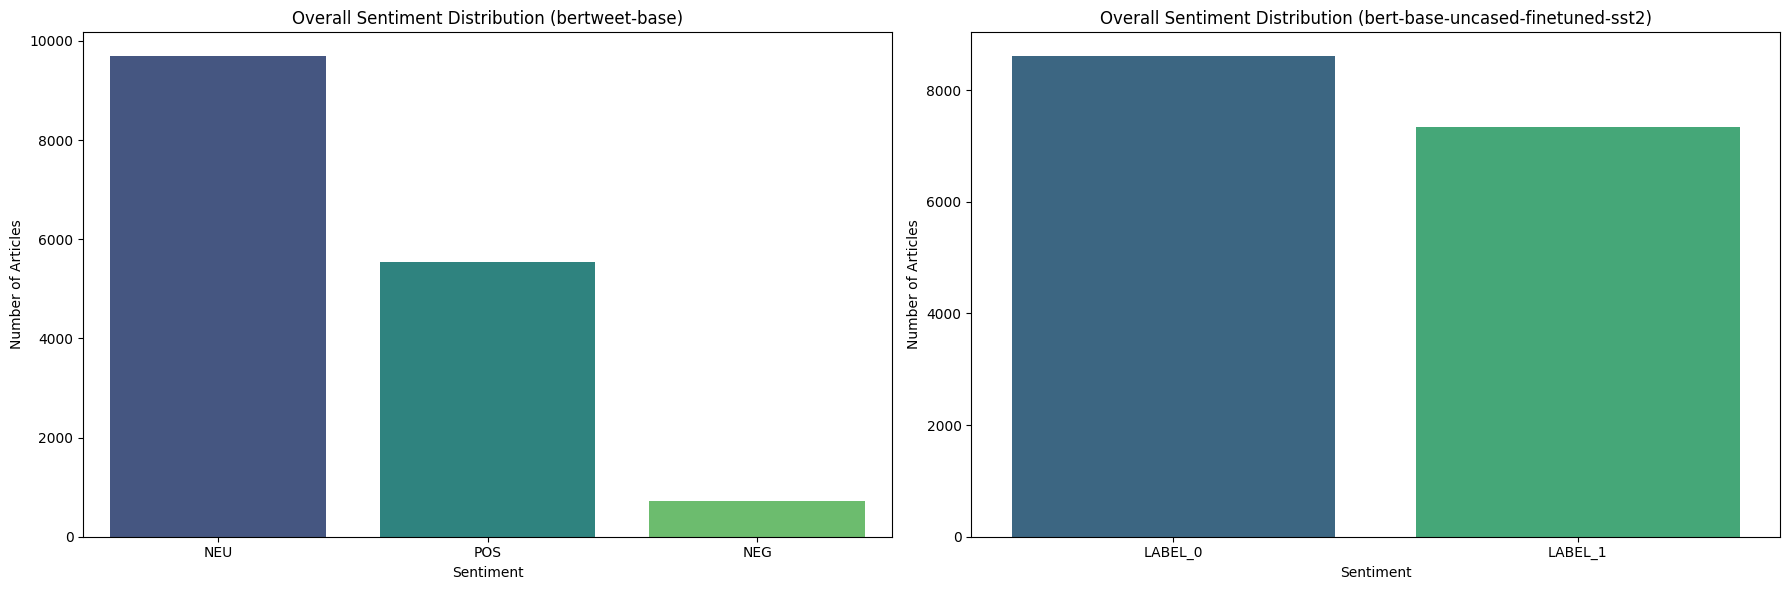

Overall sentiment distributions for both models displayed successfully.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(x='sentiment_alt', data=df, palette='viridis', hue='sentiment_alt', legend=False, ax=axes[0])
axes[0].set_title('Overall Sentiment Distribution (bertweet-base)')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Articles')

sns.countplot(x='sentiment_bert_sst2', data=df, palette='viridis', hue='sentiment_bert_sst2', legend=False, ax=axes[1])
axes[1].set_title('Overall Sentiment Distribution (bert-base-uncased-finetuned-sst2)')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Articles')

plt.tight_layout()
plt.show()
print("Overall sentiment distributions for both models displayed successfully.")

In [35]:
print("Sentiment Distribution for Original Model (distilbert-base-uncased-finetuned-sst-2-english):")
print(df['sentiment'].value_counts(normalize=True) * 100)

print("\nSentiment Distribution for Model 2 (cardiffnlp/twitter-roberta-base-sentiment-latest):")
print(df['sentiment_model2'].value_counts(normalize=True) * 100)

print("\nSentiment Distribution for Alternative Model (finiteautomata/bertweet-base-sentiment-analysis):")
print(df['sentiment_alt'].value_counts(normalize=True) * 100)

print("\nSentiment Distribution for BERT-base-uncased-finetuned-sst2 (textattack/bert-base-uncased-SST-2):")
print(df['sentiment_bert_sst2'].value_counts(normalize=True) * 100)

Sentiment Distribution for Original Model (distilbert-base-uncased-finetuned-sst-2-english):
sentiment
NEGATIVE    51.323382
POSITIVE    48.676618
Name: proportion, dtype: float64

Sentiment Distribution for Model 2 (cardiffnlp/twitter-roberta-base-sentiment-latest):
sentiment_model2
neutral     73.275213
positive    22.415956
negative     4.308831
Name: proportion, dtype: float64

Sentiment Distribution for Alternative Model (finiteautomata/bertweet-base-sentiment-analysis):
sentiment_alt
NEU    60.756397
POS    34.740341
NEG     4.503261
Name: proportion, dtype: float64

Sentiment Distribution for BERT-base-uncased-finetuned-sst2 (textattack/bert-base-uncased-SST-2):
sentiment_bert_sst2
LABEL_0    53.970146
LABEL_1    46.029854
Name: proportion, dtype: float64
